# CIFAR-10 dataset

In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import normalize

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-03-05 17:56:00.330205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Loading and observing data

In [2]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Check number of samples
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

# Check image and label shapes
print(f"Training image shape: {x_train.shape[1:]}")
print(f"Test image shape: {x_test.shape[1:]}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Training samples: 50000
Test samples: 10000
Training image shape: (32, 32, 3)
Test image shape: (32, 32, 3)
Training labels shape: (50000, 1)
Test labels shape: (10000, 1)


### Data visualization


/tmp/ipykernel_602403/1799962141.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[idx])


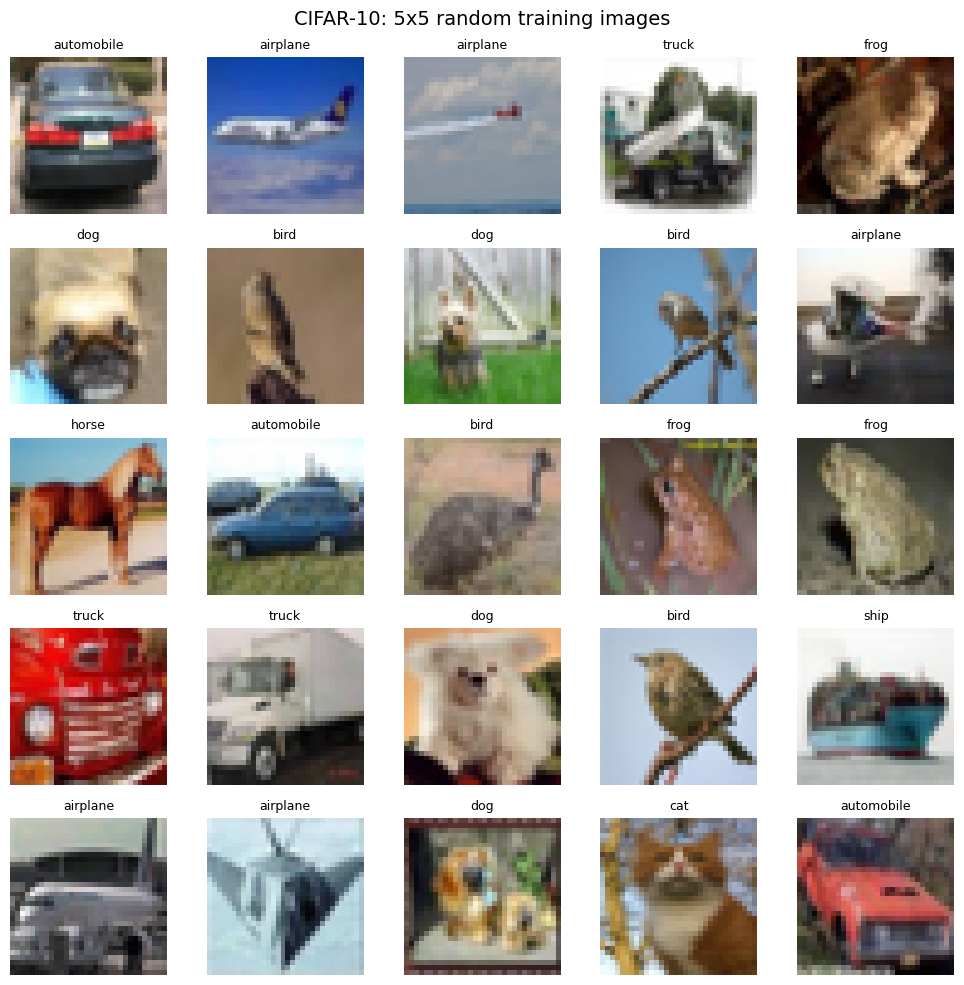

In [3]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# 5x5 completely random images
n_rows, n_cols = 5, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
random_indices = np.random.choice(len(x_train), n_rows * n_cols, replace=False)

for ax, idx in zip(axes.flat, random_indices):
    label = int(y_train[idx])
    ax.imshow(x_train[idx])
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.suptitle("CIFAR-10: 5x5 random training images", fontsize=14)
plt.tight_layout()
plt.show()


### Normalize the data

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Per-channel normalization (compute on training set only)
channel_mean = x_train.mean(axis=(0, 1, 2), keepdims=True)
channel_std = x_train.std(axis=(0, 1, 2), keepdims=True)

x_train = (x_train - channel_mean) / (channel_std + 1e-7)
x_test = (x_test - channel_mean) / (channel_std + 1e-7)

print("Channel mean:", channel_mean.reshape(-1))
print("Channel std:", channel_std.reshape(-1))


Channel mean: [0.4914009  0.48215896 0.4465308 ]
Channel std: [0.24703279 0.24348423 0.26158753]


### Transform labels into "one-hot" vectors

In [5]:
# Ensure labels are one-hot encoded exactly once
num_classes = 10

if y_train.ndim == 1:
    y_train = to_categorical(y_train, num_classes=num_classes)
elif y_train.ndim == 2 and y_train.shape[1] == 1:
    y_train = to_categorical(y_train.squeeze(), num_classes=num_classes)
elif y_train.ndim == 2 and y_train.shape[1] == num_classes:
    pass
else:
    raise ValueError(f"Unexpected y_train shape: {y_train.shape}")

if y_test.ndim == 1:
    y_test = to_categorical(y_test, num_classes=num_classes)
elif y_test.ndim == 2 and y_test.shape[1] == 1:
    y_test = to_categorical(y_test.squeeze(), num_classes=num_classes)
elif y_test.ndim == 2 and y_test.shape[1] == num_classes:
    pass
else:
    raise ValueError(f"Unexpected y_test shape: {y_test.shape}")

# Keep labels in float32 for stable and consistent training
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print("y_train shape:", y_train.shape, y_train.dtype)
print("y_test shape:", y_test.shape, y_test.dtype)


y_train shape: (50000, 10) float32
y_test shape: (10000, 10) float32


## 2. Convolutional Neural Network

### Build this network using Keras

In [6]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(shape=input_shape)

# Tiny VGG: Block 1
x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(input_layer)
x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# Tiny VGG: Block 2
x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# Classifier head
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

nb_classes = y_train.shape[1]
output_layer = tf.keras.layers.Dense(nb_classes, activation='softmax')(x)


I0000 00:00:1772729764.817831  602403 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:09:00.0, compute capability: 8.6


### Prepare and compile your model with the Adam optimizer

In [7]:
model_cnn = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

model_cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training and evaluation

In [8]:
# Reinitialize before each run to avoid continuing training from old weights
# when this cell is executed multiple times.
model_cnn = tf.keras.models.clone_model(model_cnn)
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model_cnn.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.3,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f"Best validation-loss epoch: {best_epoch}")


Epoch 1/100


2026-03-05 17:56:06.736184: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fa094005d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-05 17:56:06.736199: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-05 17:56:06.758354: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-05 17:56:06.891623: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 48/274 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1852 - loss: 2.2004

I0000 00:00:1772729768.975599  602970 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3342 - loss: 1.8916

2026-03-05 17:56:09.999961: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-05 17:56:10.279558: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_440', 8 bytes spill stores, 8 bytes spill loads

2026-03-05 17:56:10.421261: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_686', 92 bytes spill stores, 92 bytes spill loads

2026-03-05 17:56:10.569781: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_686', 520 bytes 

274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4287 - loss: 1.6829 - val_accuracy: 0.5072 - val_loss: 1.5113 - learning_rate: 3.0000e-04
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5638 - loss: 1.3638 - val_accuracy: 0.5841 - val_loss: 1.3149 - learning_rate: 3.0000e-04
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6257 - loss: 1.2286 - val_accuracy: 0.6293 - val_loss: 1.2299 - learning_rate: 3.0000e-04
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6707 - loss: 1.1284 - val_accuracy: 0.6477 - val_loss: 1.1815 - learning_rate: 3.0000e-04
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7054 - loss: 1.0481 - val_accuracy: 0.6807 - val_loss: 1.1091 - learning_rate: 3.0000e-04
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7308 - loss: 0.9847 - val_accuracy: 0.6893 - val_loss: 1.0819 - learning_rate: 3.0000e-04
Epoch 7/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.75

### Evaluate your model on the test set

In [9]:
test_loss, test_accuracy = model_cnn.evaluate(x_test, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

2026-03-05 17:56:36.785718: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_147', 20 bytes spill stores, 20 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7218 - loss: 1.0315
Test loss: 1.0315
Test accuracy: 0.7218


### Sanity checks for loss and accuracy


In [10]:
# Basic data/label sanity checks
print("x_train:", x_train.shape, x_train.dtype, "min=", float(x_train.min()), "max=", float(x_train.max()))
print("x_test :", x_test.shape, x_test.dtype, "min=", float(x_test.min()), "max=", float(x_test.max()))
print("y_train:", y_train.shape, y_train.dtype)
print("y_test :", y_test.shape, y_test.dtype)

assert y_train.ndim == 2 and y_train.shape[1] == 10, f"Unexpected y_train shape: {y_train.shape}"
assert y_test.ndim == 2 and y_test.shape[1] == 10, f"Unexpected y_test shape: {y_test.shape}"
assert np.allclose(y_train.sum(axis=1), 1.0), "y_train rows are not valid one-hot vectors"
assert np.allclose(y_test.sum(axis=1), 1.0), "y_test rows are not valid one-hot vectors"

# Recompute metrics manually from predicted probabilities
probs = model_cnn.predict(x_test, batch_size=256, verbose=0)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(probs, axis=1)

auto_acc = float(np.mean(y_true == y_pred))
true_prob = probs[np.arange(len(y_true)), y_true]
manual_ce = float(np.mean(-np.log(np.clip(true_prob, 1e-9, 1.0))))

print(f"Manual test accuracy: {auto_acc:.4f}")
print(f"Manual test cross-entropy: {manual_ce:.4f}")

correct_mask = (y_true == y_pred)
print(f"Mean true-class prob (correct preds): {float(true_prob[correct_mask].mean()):.4f}")
print(f"Mean true-class prob (wrong preds)  : {float(true_prob[~correct_mask].mean()):.4f}")


x_train: (50000, 32, 32, 3) float32 min= -1.9892123937606812 max= 2.1267940998077393
x_test : (10000, 32, 32, 3) float32 min= -1.9892123937606812 max= 2.1267940998077393
y_train: (50000, 10) float32
y_test : (10000, 10) float32
Manual test accuracy: 0.7218
Manual test cross-entropy: 0.8209
Mean true-class prob (correct preds): 0.7960
Mean true-class prob (wrong preds)  : 0.1653


### Plot the train and test curves (accuracy and loss)

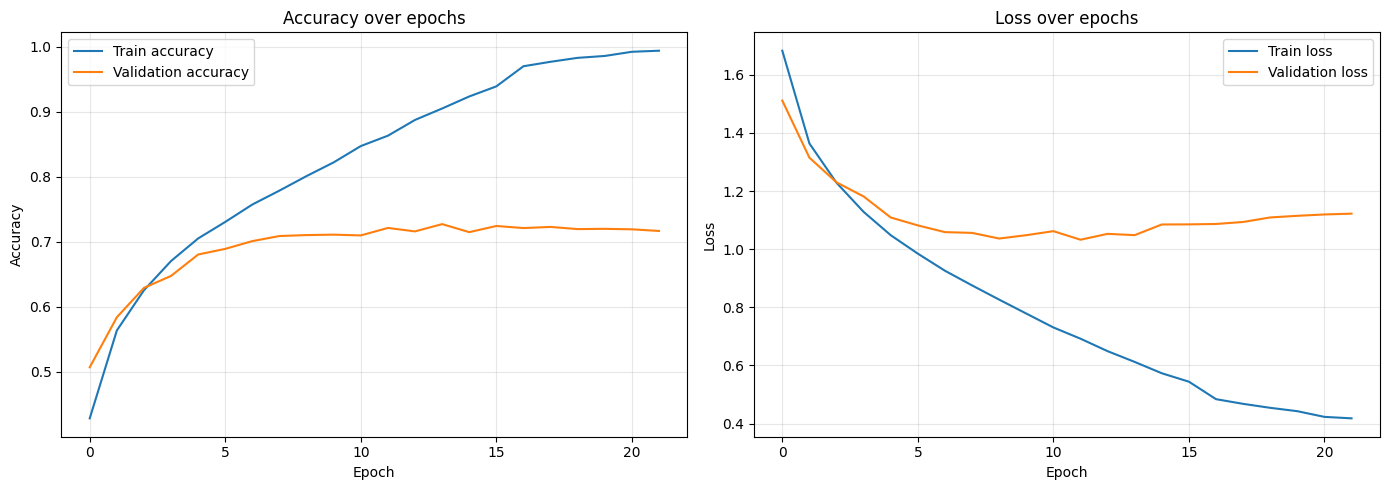

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Robustness to random initialization
Train the same model several times and report mean test accuracy with standard deviation.


In [ ]:
def build_tiny_vgg(input_shape, num_classes):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Classifier
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model

n_runs = 5
epochs = 100
batch_size = 128
validation_split = 0.3

run_accuracies = []
run_losses = []

for run in range(n_runs):
    tf.keras.backend.clear_session()

    # Different seed at each run to probe initialization sensitivity
    tf.keras.utils.set_random_seed(42 + run)

    model = build_tiny_vgg(x_train.shape[1:], y_train.shape[1])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0
        ),
    ]

    _ = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=callbacks,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    run_losses.append(test_loss)
    run_accuracies.append(test_acc)
    print(f"Run {run + 1}/{n_runs} - test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

run_accuracies = np.array(run_accuracies)
run_losses = np.array(run_losses)

print("\nRobustness summary")
print(f"Accuracy mean: {run_accuracies.mean():.4f}")
print(f"Accuracy std : {run_accuracies.std(ddof=1):.4f}")
print(f"Loss mean    : {run_losses.mean():.4f}")
print(f"Loss std     : {run_losses.std(ddof=1):.4f}")


### Robustness visualization


In [ ]:
runs = np.arange(1, len(run_accuracies) + 1)

plt.figure(figsize=(8, 4))
plt.plot(runs, run_accuracies, marker='o')
plt.axhline(run_accuracies.mean(), color='red', linestyle='--', label='Mean accuracy')
plt.fill_between(
    runs,
    run_accuracies.mean() - run_accuracies.std(ddof=1),
    run_accuracies.mean() + run_accuracies.std(ddof=1),
    color='red',
    alpha=0.15,
    label='Mean ± std'
)
plt.xticks(runs)
plt.xlabel('Run')
plt.ylabel('Test accuracy')
plt.title('Model robustness across random initializations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Visualization of intermediate features and kernels


### 10) Visualize intermediate feature maps (one selected filter)


In [ ]:
# Visualize one selected filter across intermediate Conv/Pool feature maps
selected_filter = 0  # choose from 0..9 (or any valid channel index)
sample_index = 0

intermediate_layers = [
    layer for layer in model_cnn.layers
    if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D))
]

activation_model = tf.keras.Model(
    inputs=model_cnn.input,
    outputs=[layer.output for layer in intermediate_layers]
)

sample = x_test[sample_index:sample_index + 1]
feature_maps = activation_model.predict(sample, verbose=0)

n_layers = len(intermediate_layers)
fig, axes = plt.subplots(1, n_layers, figsize=(4 * n_layers, 4))
if n_layers == 1:
    axes = [axes]

for ax, layer, fmap in zip(axes, intermediate_layers, feature_maps):
    channel_id = min(selected_filter, fmap.shape[-1] - 1)
    ax.imshow(fmap[0, :, :, channel_id], cmap='viridis')
    ax.set_title(f"{layer.name}\nfilter {channel_id}")
    ax.axis('off')

plt.suptitle('Intermediate feature maps for one filter', fontsize=13)
plt.tight_layout()
plt.show()


### 11) Visualize first-layer kernels of tiny VGG (all filters, per RGB channel)


In [ ]:
# Visualize all kernels from the first Conv2D layer of model_cnn
first_conv = next(layer for layer in model_cnn.layers if isinstance(layer, tf.keras.layers.Conv2D))
kernels = first_conv.get_weights()[0]  # shape: (kh, kw, in_channels, out_channels)

kh, kw, in_channels, out_channels = kernels.shape
print('First conv kernel shape:', kernels.shape)

# Show per input channel (R, G, B)
channel_names = ['R', 'G', 'B']
cols = 8
rows = int(np.ceil(out_channels / cols))

for c in range(in_channels):
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for i, ax in enumerate(axes.flat):
        if i < out_channels:
            kernel_2d = kernels[:, :, c, i]
            kmin, kmax = kernel_2d.min(), kernel_2d.max()
            kernel_2d = (kernel_2d - kmin) / (kmax - kmin + 1e-8)
            ax.imshow(kernel_2d, cmap='gray')
            ax.set_title(f'F{i}', fontsize=8)
        ax.axis('off')

    ch_name = channel_names[c] if c < len(channel_names) else f'C{c}'
    plt.suptitle(f'First-layer kernels - input channel {ch_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


### 12) Load pretrained ResNet50 and visualize first 64 filters as RGB images


In [ ]:
# Load a new pretrained model variable and visualize first-layer filters
# Note: first execution may download ImageNet weights.
resnet50_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=True)
resnet_first_conv = resnet50_model.get_layer('conv1_conv')
resnet_kernels = resnet_first_conv.get_weights()[0]  # (7, 7, 3, 64)

print('ResNet50 first conv kernel shape:', resnet_kernels.shape)

n_filters = resnet_kernels.shape[-1]
cols = 8
rows = int(np.ceil(n_filters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(rows, cols)

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        k = resnet_kernels[:, :, :, i]
        k = (k - k.min()) / (k.max() - k.min() + 1e-8)
        ax.imshow(k)
        ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')

plt.suptitle('ResNet50 first-layer filters (RGB)', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Improving the model


### Shared experiment utility (for Q13-Q15)


In [ ]:
def run_robustness_experiment(
    model_builder,
    model_name,
    x_train,
    y_train,
    x_test,
    y_test,
    n_runs=5,
    epochs=100,
    batch_size=128,
    validation_split=0.3,
    seed_base=1000,
):
    run_accuracies = []
    run_losses = []

    for run in range(n_runs):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seed_base + run)

        model = model_builder(input_shape=x_train.shape[1:], num_classes=y_train.shape[1])

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0
            ),
        ]

        model.fit(
            x_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=0,
        )

        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        run_losses.append(test_loss)
        run_accuracies.append(test_acc)
        print(f"{model_name} - Run {run + 1}/{n_runs}: loss={test_loss:.4f}, acc={test_acc:.4f}")

    run_losses = np.array(run_losses)
    run_accuracies = np.array(run_accuracies)

    print(f"\n{model_name} summary")
    print(f"Accuracy mean: {run_accuracies.mean():.4f}")
    print(f"Accuracy std : {run_accuracies.std(ddof=1):.4f}")
    print(f"Loss mean    : {run_losses.mean():.4f}")
    print(f"Loss std     : {run_losses.std(ddof=1):.4f}")

    return {
        'name': model_name,
        'losses': run_losses,
        'accuracies': run_accuracies,
        'acc_mean': run_accuracies.mean(),
        'acc_std': run_accuracies.std(ddof=1),
        'loss_mean': run_losses.mean(),
        'loss_std': run_losses.std(ddof=1),
    }


def plot_run_accuracies(results):
    runs = np.arange(1, len(results['accuracies']) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(runs, results['accuracies'], marker='o')
    plt.axhline(results['acc_mean'], color='red', linestyle='--', label='Mean accuracy')
    plt.fill_between(
        runs,
        results['acc_mean'] - results['acc_std'],
        results['acc_mean'] + results['acc_std'],
        color='red',
        alpha=0.15,
        label='Mean +/- std',
    )
    plt.title(f"{results['name']} robustness")
    plt.xlabel('Run')
    plt.ylabel('Test accuracy')
    plt.xticks(runs)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


### 13) Tiny VGG + BatchNormalization after each convolution


In [ ]:
def build_tiny_vgg_bn(input_shape, num_classes):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model

bn_results = run_robustness_experiment(
    model_builder=build_tiny_vgg_bn,
    model_name='Tiny VGG + BN',
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    n_runs=5,
    epochs=100,
    batch_size=128,
    validation_split=0.3,
    seed_base=2000,
)

plot_run_accuracies(bn_results)


### 14) Add one additional convolution block to original tiny VGG


In [ ]:
def build_tiny_vgg_3blocks(input_shape, num_classes):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # Additional Block 3
    x = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model

vgg3_results = run_robustness_experiment(
    model_builder=build_tiny_vgg_3blocks,
    model_name='Tiny VGG (3 blocks)',
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    n_runs=5,
    epochs=100,
    batch_size=128,
    validation_split=0.3,
    seed_base=3000,
)

plot_run_accuracies(vgg3_results)


### 15) Tiny ResNet-like architecture and robustness experiment


In [ ]:
def residual_block(x, filters, block_name):
    shortcut = x

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', use_bias=False, name=f'{block_name}_conv1')(x)
    x = tf.keras.layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = tf.keras.layers.Activation('relu', name=f'{block_name}_act1')(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same', use_bias=False, name=f'{block_name}_conv2')(x)
    x = tf.keras.layers.BatchNormalization(name=f'{block_name}_bn2')(x)

    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding='same', use_bias=False, name=f'{block_name}_proj')(shortcut)
        shortcut = tf.keras.layers.BatchNormalization(name=f'{block_name}_proj_bn')(shortcut)

    x = tf.keras.layers.Add(name=f'{block_name}_add')([x, shortcut])
    x = tf.keras.layers.Activation('relu', name=f'{block_name}_out')(x)
    return x


def build_tiny_resnet_like(input_shape, num_classes):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Stem: 7x7 conv -> BN -> ReLU -> MaxPool(2)
    x = tf.keras.layers.Conv2D(32, (7, 7), padding='same', use_bias=False, name='stem_conv')(inputs)
    x = tf.keras.layers.BatchNormalization(name='stem_bn')(x)
    x = tf.keras.layers.Activation('relu', name='stem_relu')(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name='stem_pool')(x)

    # Residual blocks (without max pooling inside blocks)
    x = residual_block(x, filters=32, block_name='block1')
    x = residual_block(x, filters=64, block_name='block2')

    # "Global" average pooling with pool_size=4, then flatten
    x = tf.keras.layers.AveragePooling2D(pool_size=(4, 4), name='avg_pool_4')(x)
    x = tf.keras.layers.Flatten(name='flatten')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='classifier')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model

resnet_like_results = run_robustness_experiment(
    model_builder=build_tiny_resnet_like,
    model_name='Tiny ResNet-like',
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    n_runs=5,
    epochs=100,
    batch_size=128,
    validation_split=0.3,
    seed_base=4000,
)

plot_run_accuracies(resnet_like_results)


### Quick comparison table (Q13-Q15)


In [ ]:
comparison = [bn_results, vgg3_results, resnet_like_results]

print('Model comparison (mean +/- std on test accuracy)')
for r in comparison:
    print(f"- {r['name']}: {r['acc_mean']:.4f} +/- {r['acc_std']:.4f}")
